Create a model to predict whether or not a custumer will Churn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Telco-Customer-Churn.csv')

First thing, we need make a quick check in our data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


(EDA) - Exploratory data Analysis

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df['Churn'].value_counts()

No     5163
Yes    1869
Name: Churn, dtype: int64

<AxesSubplot:xlabel='Churn', ylabel='count'>

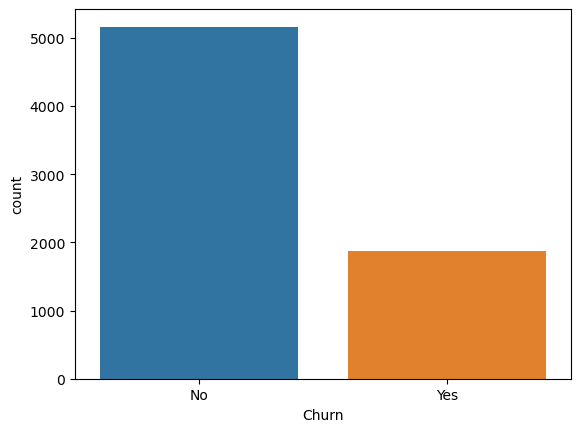

In [8]:
sns.countplot(data=df, x='Churn')

<AxesSubplot:xlabel='Churn', ylabel='TotalCharges'>

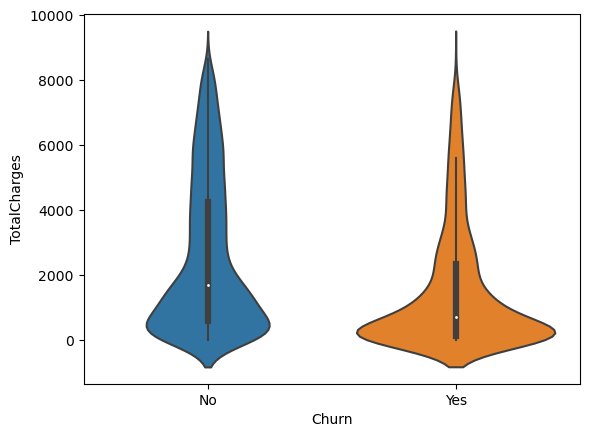

In [11]:
sns.violinplot(data=df, x='Churn', y='TotalCharges')

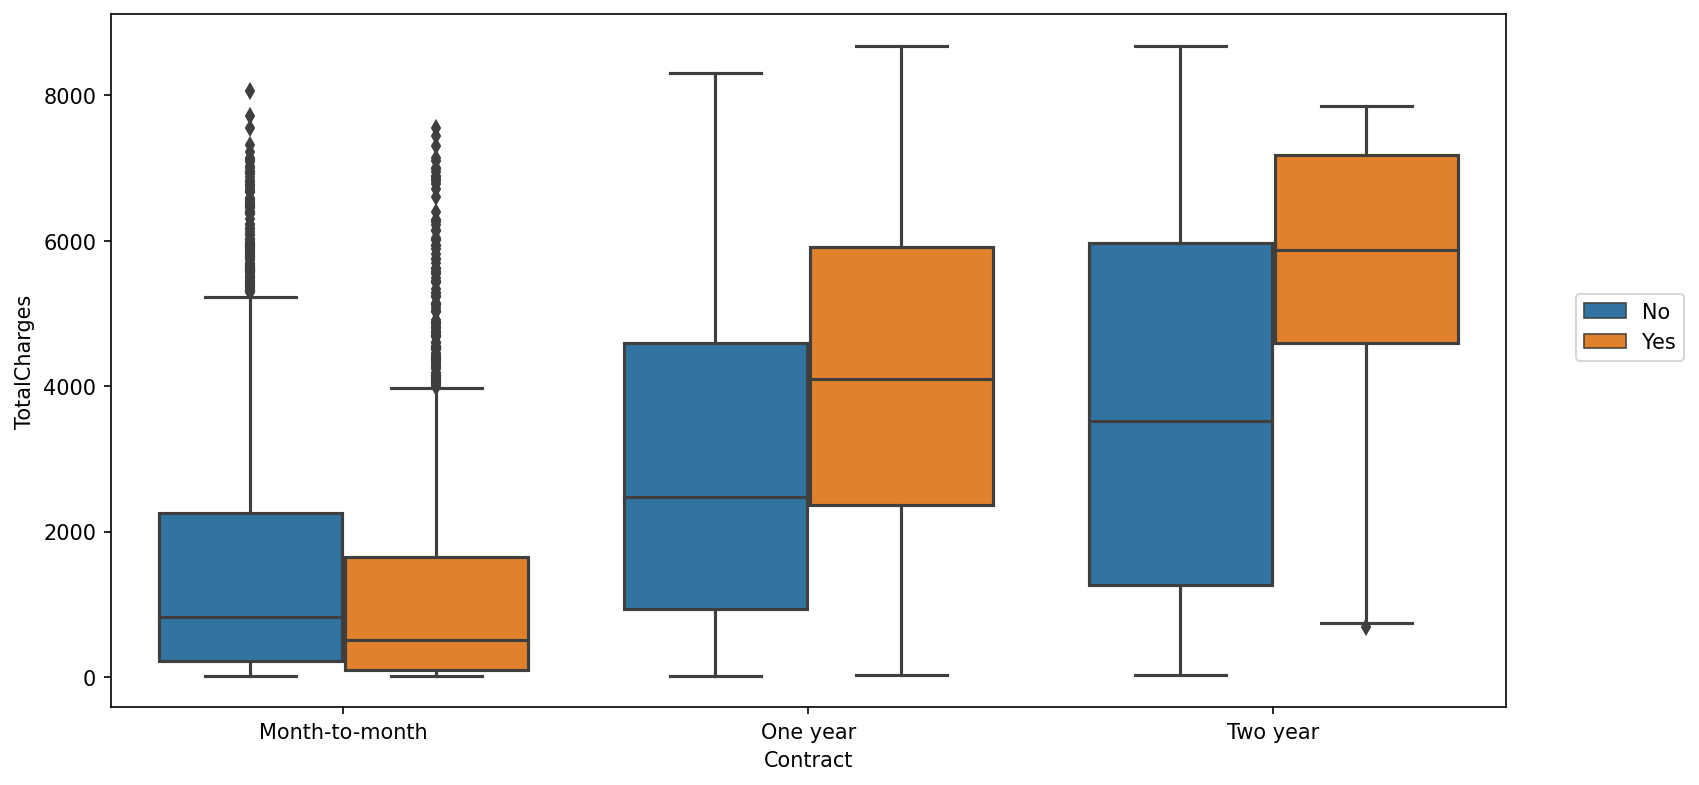

In [21]:
plt.figure(figsize=(12,6),dpi=150)
sns.boxplot(data=df, x='Contract', y='TotalCharges', hue='Churn')
plt.legend(loc=(1.05,0.5))

In [28]:
correlation_df = pd.get_dummies(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 
 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
   'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod','Churn']]).corr()

In [32]:
yes_churn_corr = correlation_df['Churn_Yes'].sort_values().iloc[1:-1]

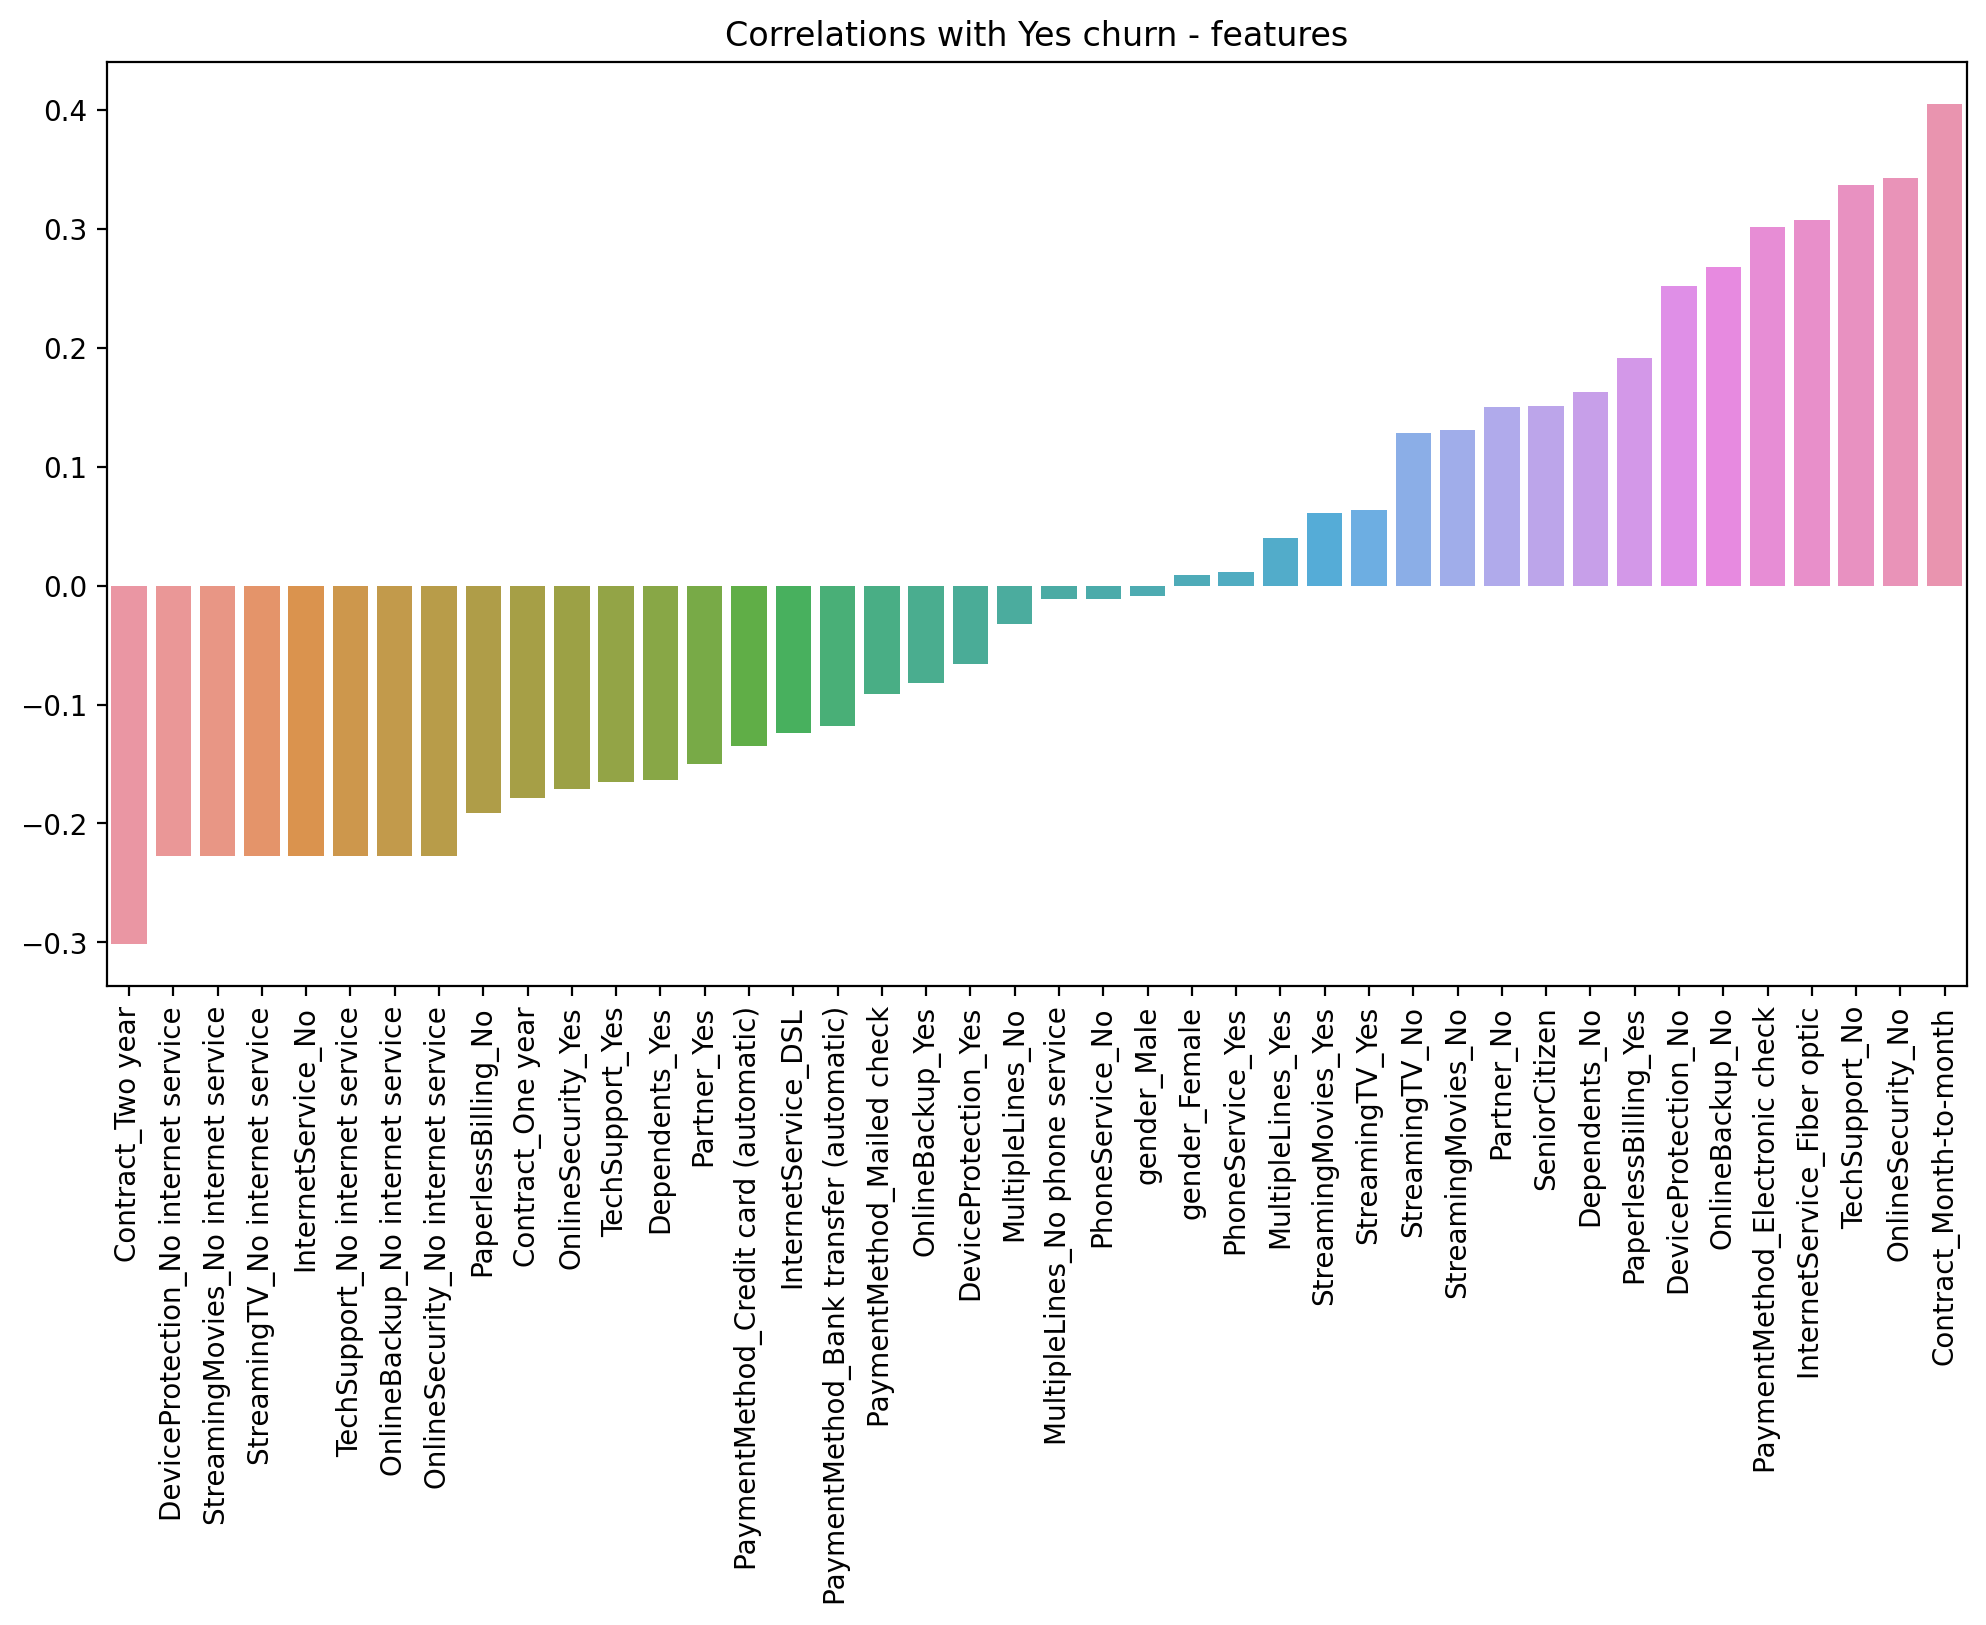

In [39]:
plt.figure(figsize=(12,6),dpi=200)
plt.title('Correlations with Yes churn - features')
sns.barplot(x=yes_churn_corr.index, y=yes_churn_corr.values, data=df)
plt.xticks(rotation=90);

    Churn analysis, i gonna focuses on segmenting customers and create cohorts

In [40]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26, 39], dtype=int64)

In [41]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

<AxesSubplot:xlabel='tenure', ylabel='Count'>

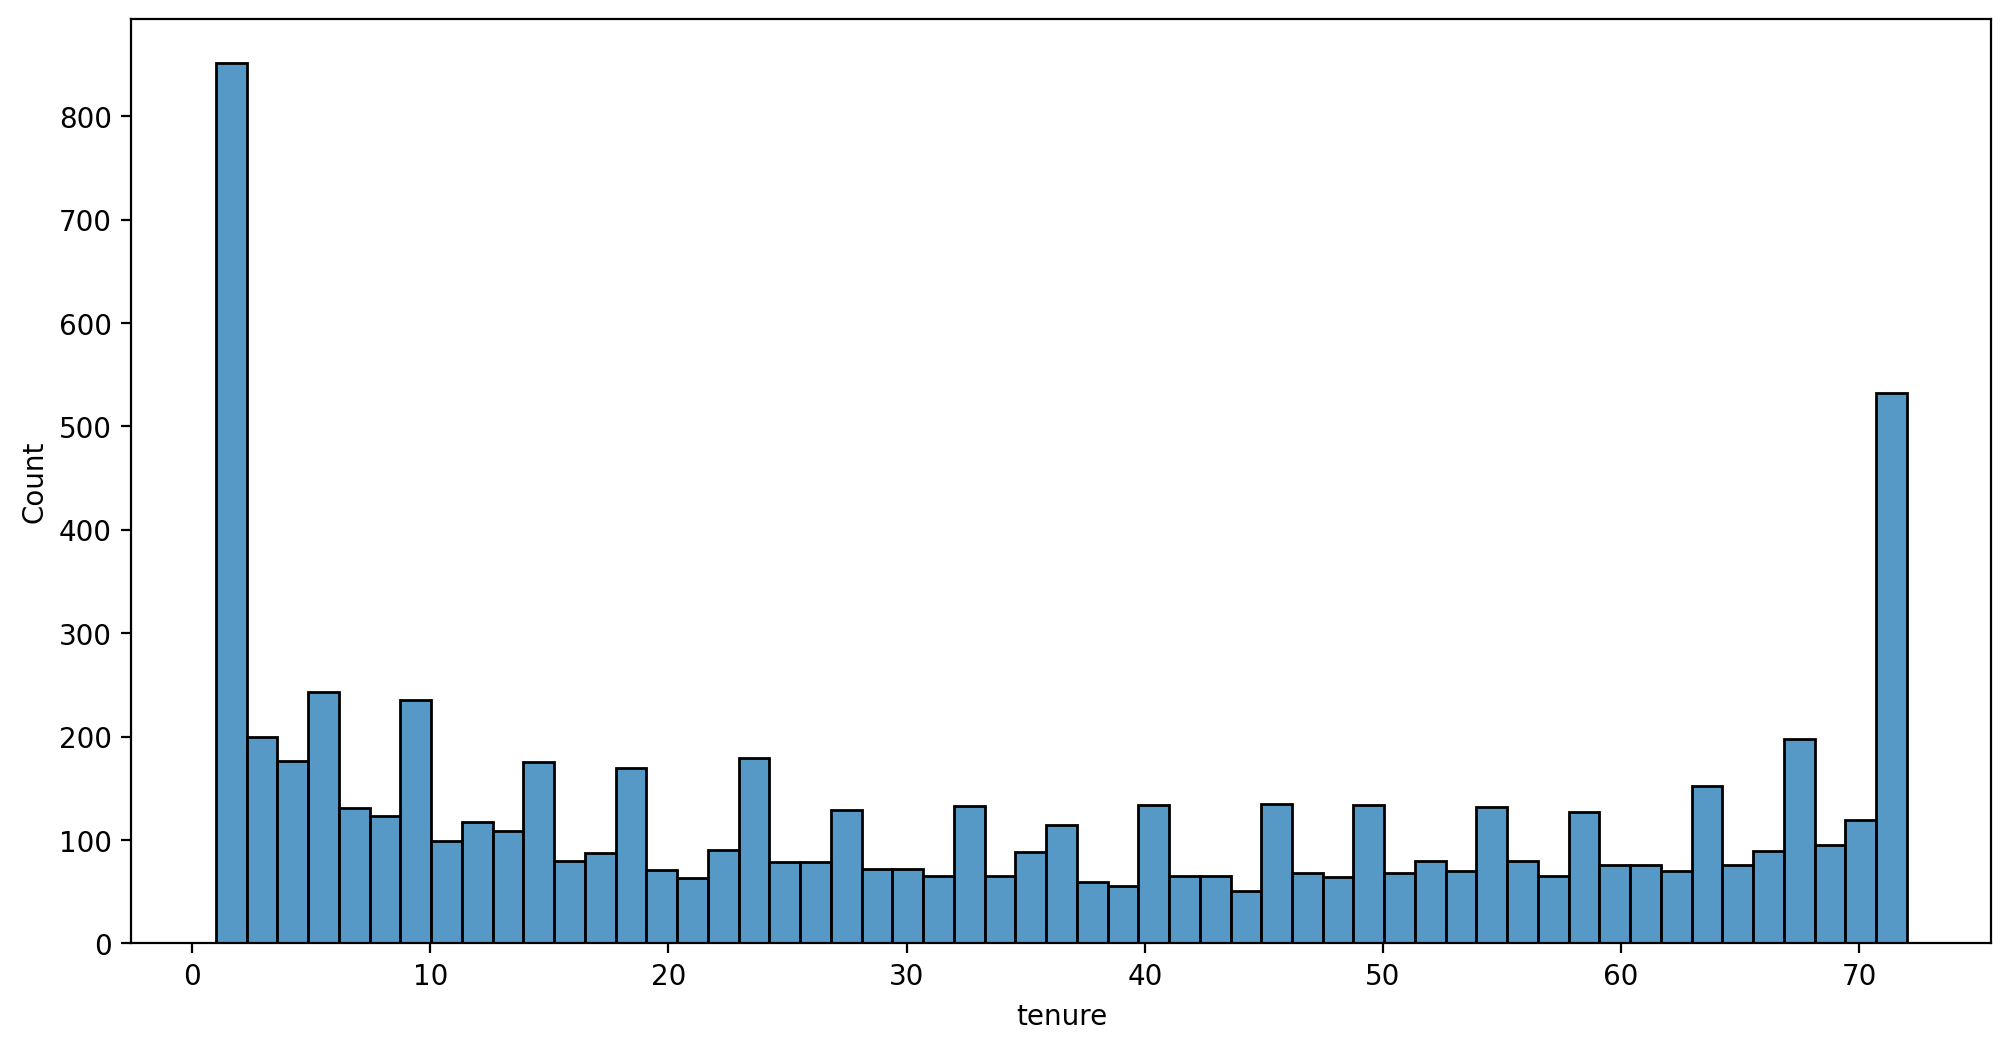

In [47]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df, x='tenure', bins=55)

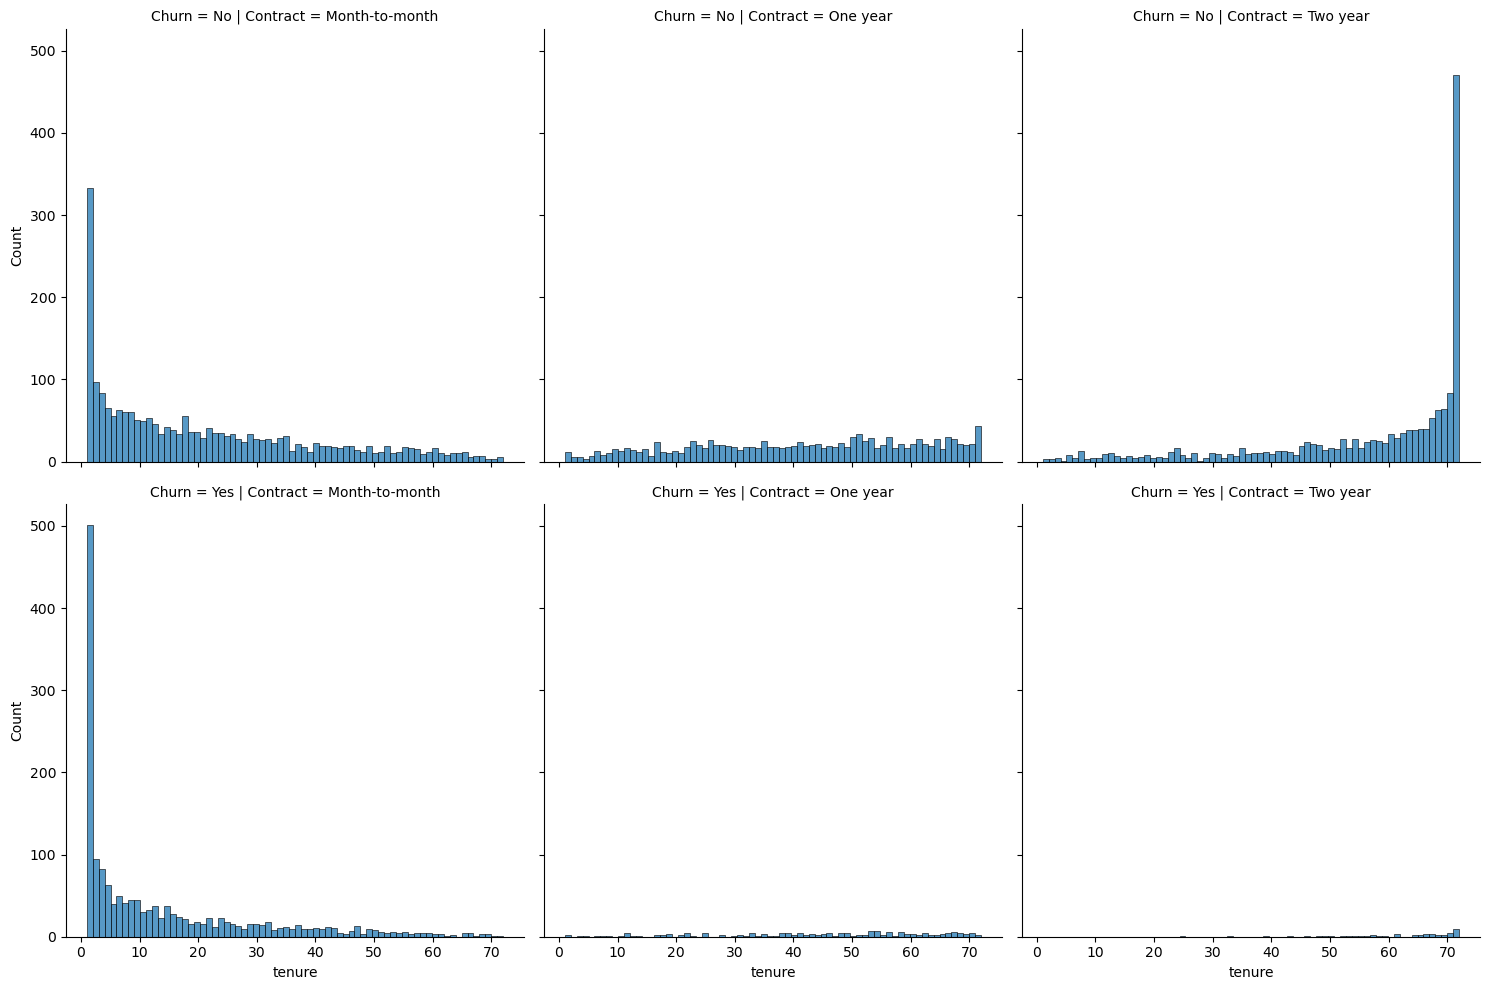

In [51]:
sns.displot(data=df, x='tenure', bins=70, col='Contract', row='Churn')

<AxesSubplot:xlabel='MonthlyCharges', ylabel='TotalCharges'>

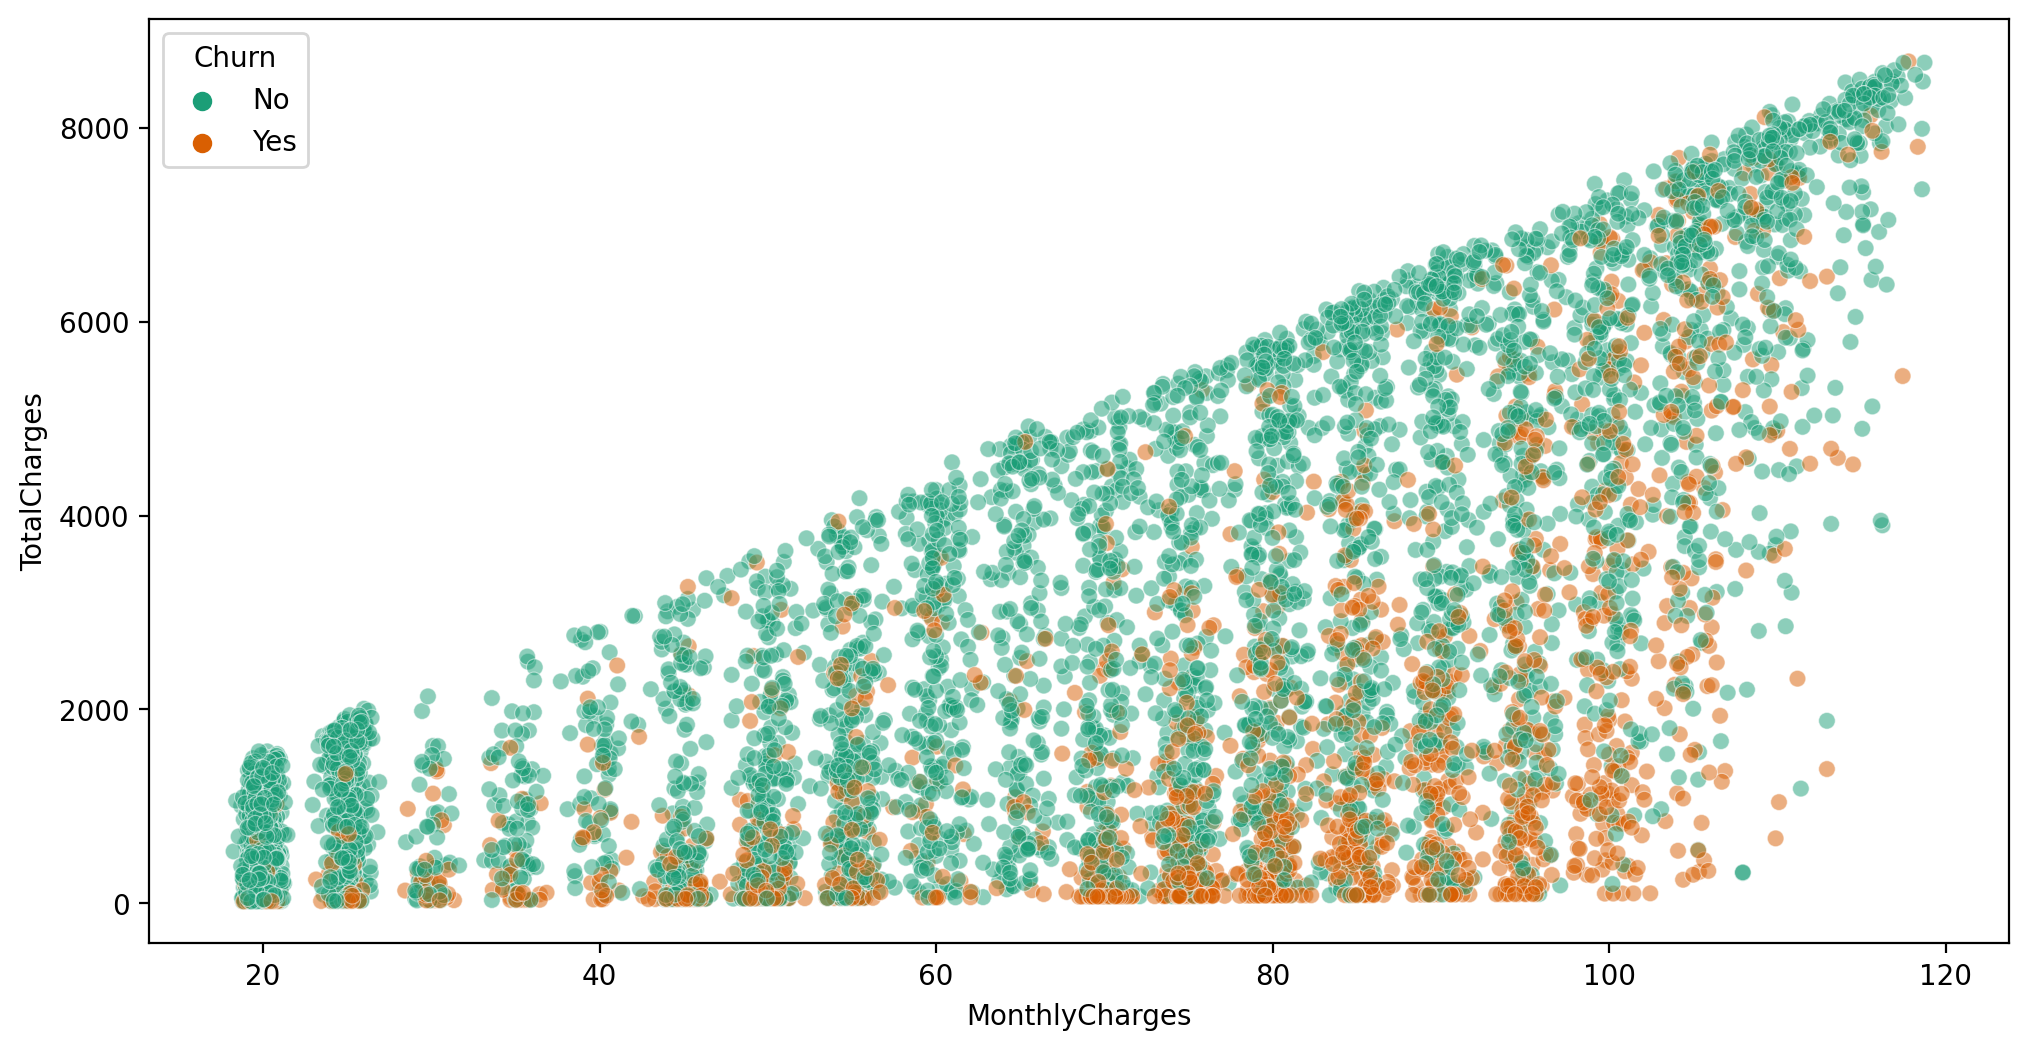

In [58]:
plt.figure(figsize=(12,6),dpi=200)
sns.scatterplot(data=df, y='TotalCharges', x='MonthlyCharges', hue='Churn', alpha=0.5, linewidth=0.4, palette='Dark2')

Cohorts based on Tenure

In [64]:
yes_churn = df.groupby(['Churn','tenure']).count().transpose()['Yes']

In [65]:
no_churn = df.groupby(['Churn','tenure']).count().transpose()['No']

In [69]:
churn_rate = 100*yes_churn / (no_churn+yes_churn)

<AxesSubplot:xlabel='tenure'>

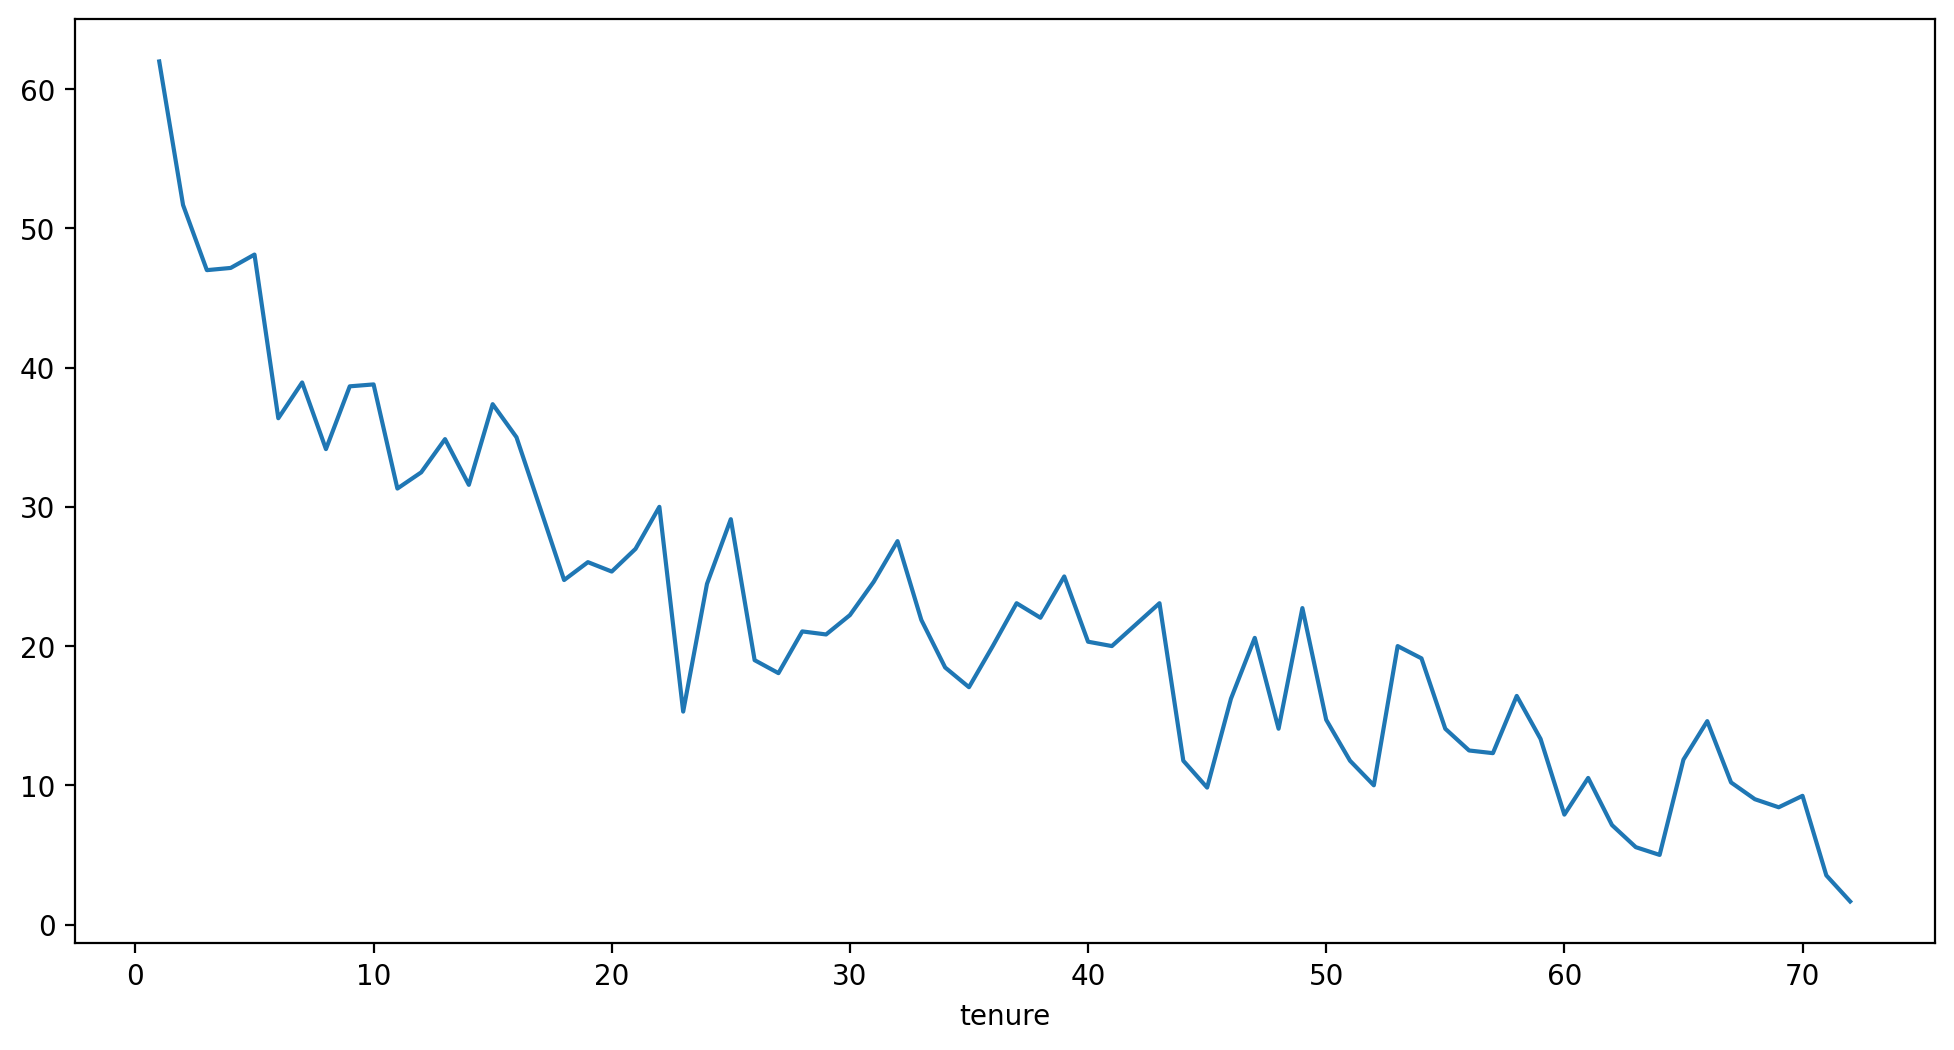

In [75]:
plt.figure(figsize=(12,6),dpi=200)
churn_rate.transpose()['customerID'].plot()

In [79]:
def cohort(tenure):
    if tenure<13:
        return '0-12 Months'
    elif tenure<25:
        return '12-24 Months'
    elif tenure<49:
        return '24-48 Months'
    else:
        return 'Over 48 Months'

In [82]:
df['Tenure Cohort'] = df['tenure'].apply(cohort)

In [83]:
df[['Tenure Cohort','tenure']]

,Tenure Cohort,tenure
0,0-12 Months,1
1,24-48 Months,34
2,0-12 Months,2
3,24-48 Months,45
4,0-12 Months,2
...,...,...
7027,12-24 Months,24
7028,Over 48 Months,72
7029,0-12 Months,11
7030,0-12 Months,4


<AxesSubplot:xlabel='MonthlyCharges', ylabel='TotalCharges'>

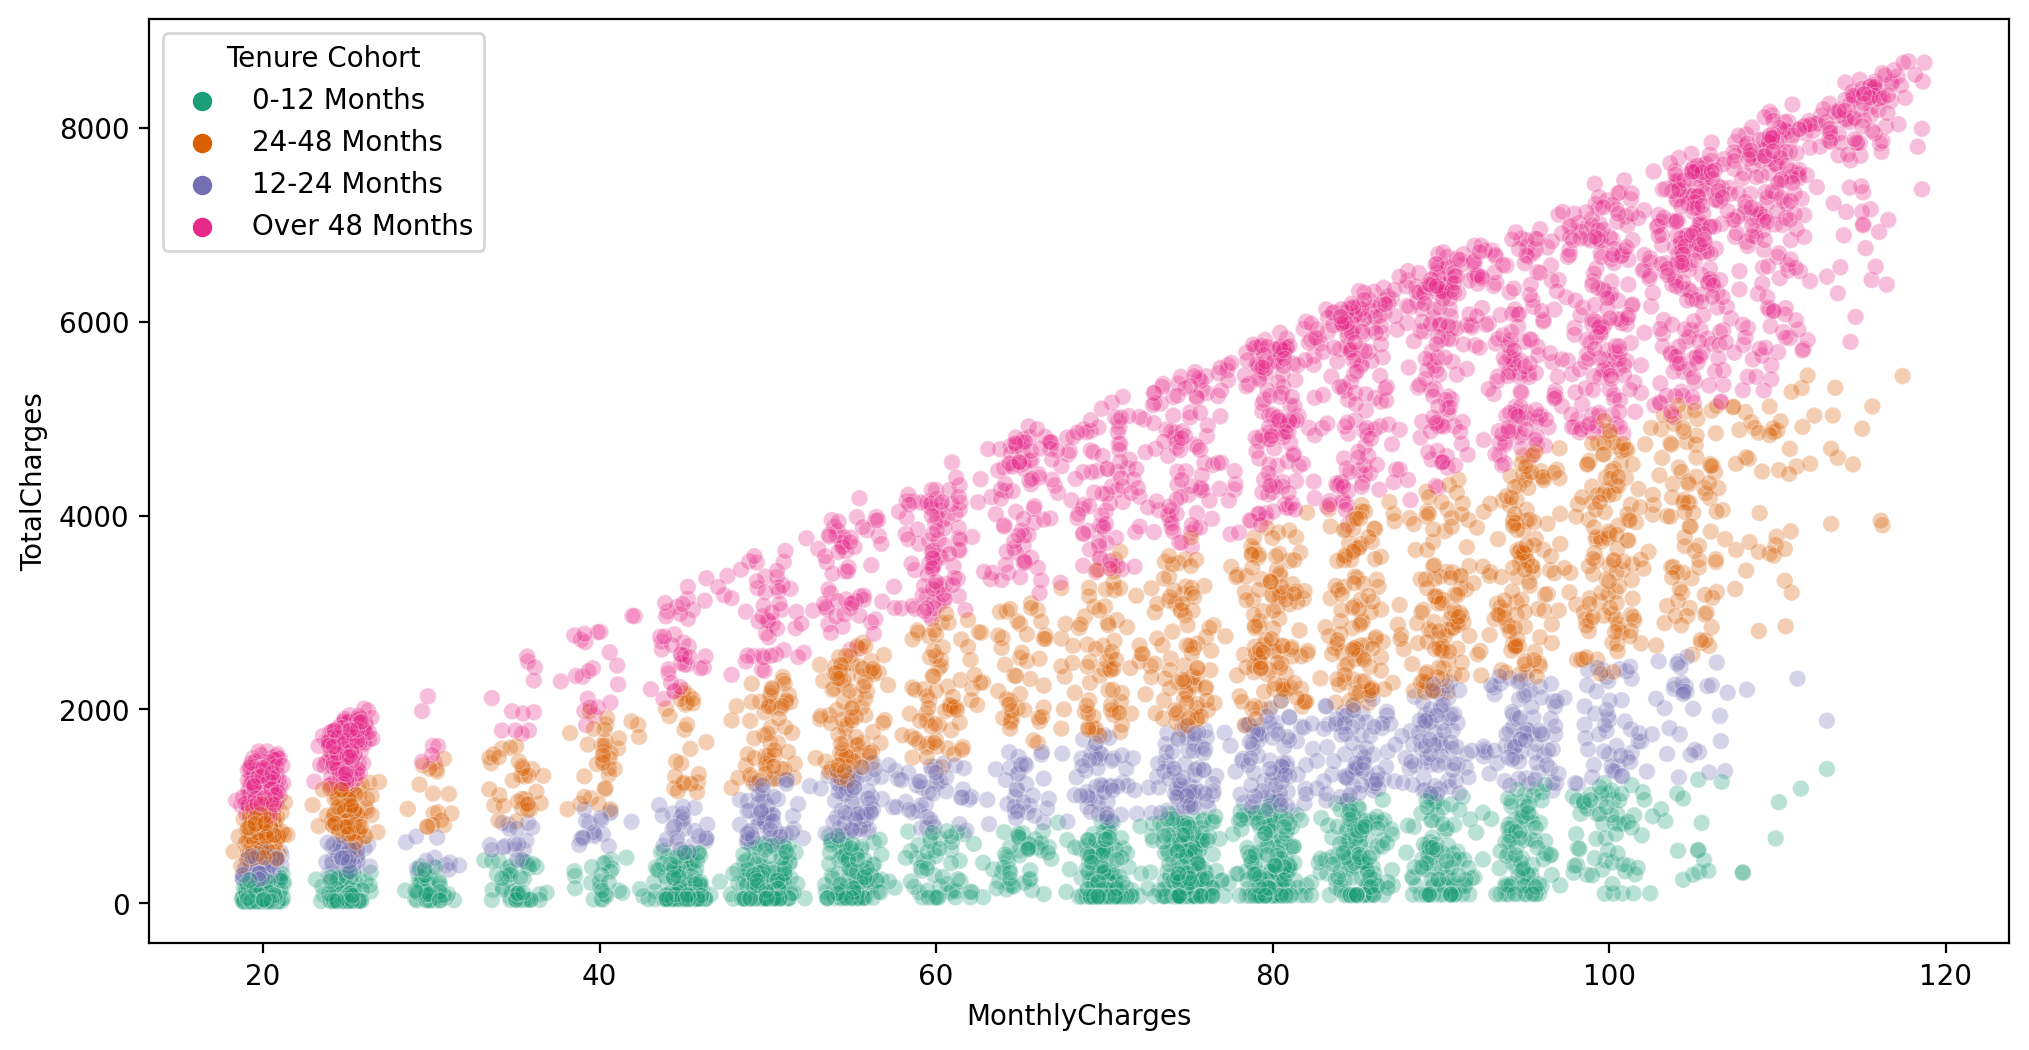

In [85]:
plt.figure(figsize=(12,6),dpi=200)
sns.scatterplot(data=df, y='TotalCharges', x='MonthlyCharges', hue='Tenure Cohort', alpha=0.3, linewidth=0.4, palette='Dark2')

<AxesSubplot:xlabel='Tenure Cohort', ylabel='count'>

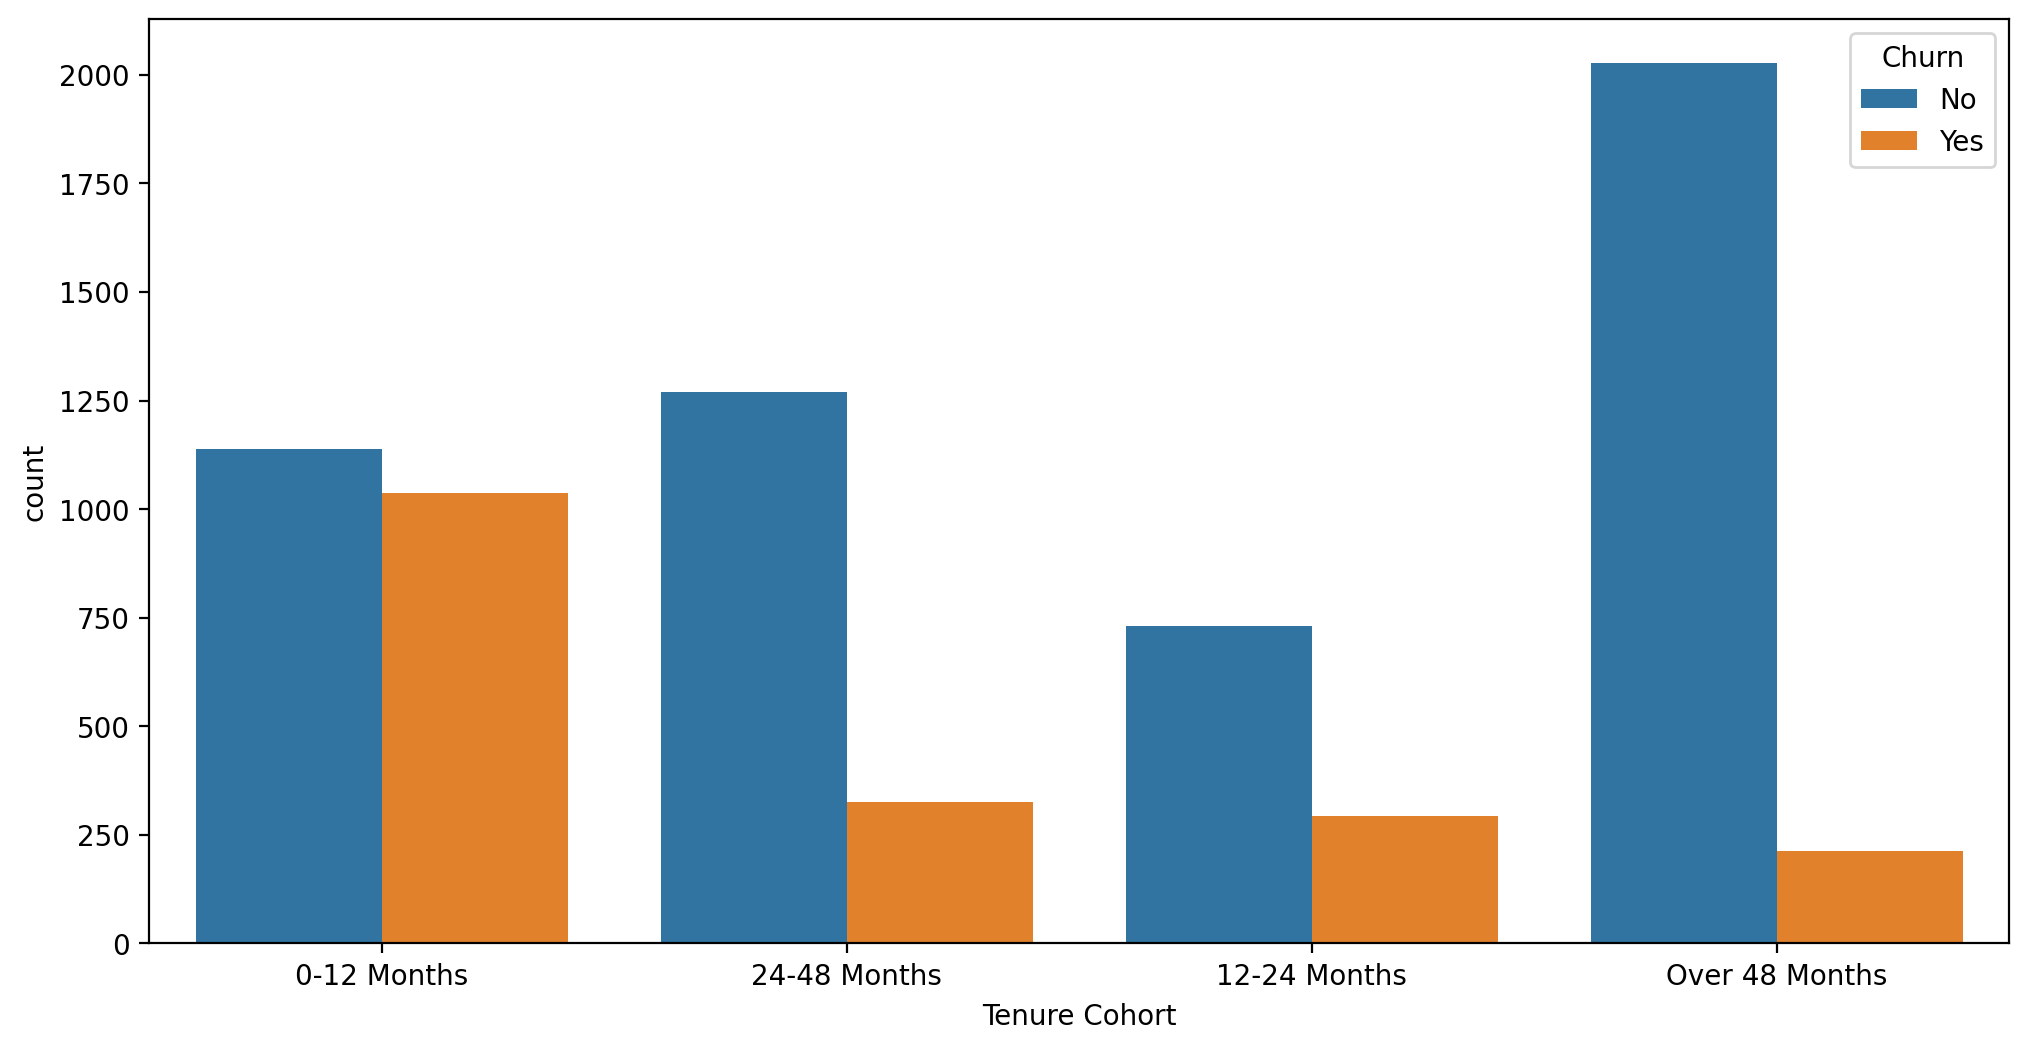

In [87]:
plt.figure(figsize=(12,6),dpi=200)
sns.countplot(data=df, x='Tenure Cohort', hue='Churn')

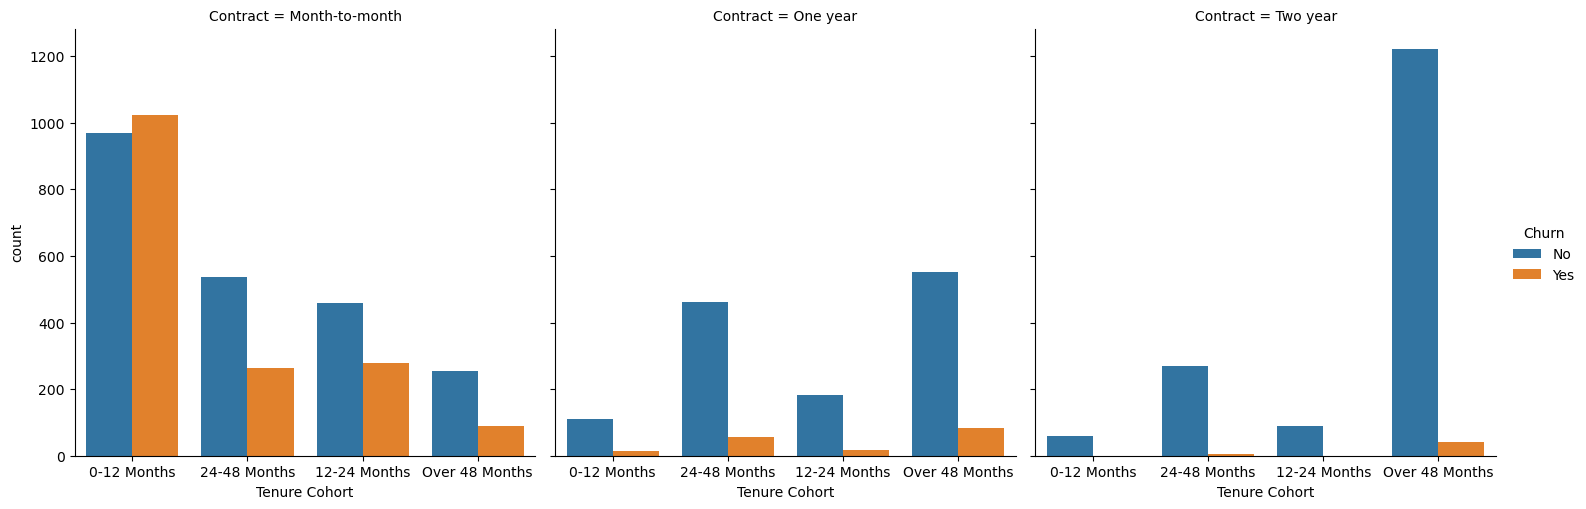

In [89]:
sns.catplot(data=df, x='Tenure Cohort', hue='Churn', kind='count', col='Contract')

PREDICTIVE MODELING
TRY 4 DIFFERENT TREE BASED MODELS

Single Decision Tree

In [92]:
X = df.drop(['Churn','customerID'],axis=1)

In [93]:
X = pd.get_dummies(X,drop_first=True)

In [94]:
y = df['Churn']

In [96]:
from sklearn.model_selection import train_test_split

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=101)

In [98]:
from sklearn.tree import DecisionTreeClassifier

In [100]:
dtc = DecisionTreeClassifier(max_depth=6)

In [101]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=6)

In [102]:
from sklearn.metrics import plot_confusion_matrix,classification_report

In [103]:
preds = dtc.predict(X_test)

In [104]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

          No       0.87      0.89      0.88       557
         Yes       0.55      0.49      0.52       147

    accuracy                           0.81       704
   macro avg       0.71      0.69      0.70       704
weighted avg       0.80      0.81      0.80       704



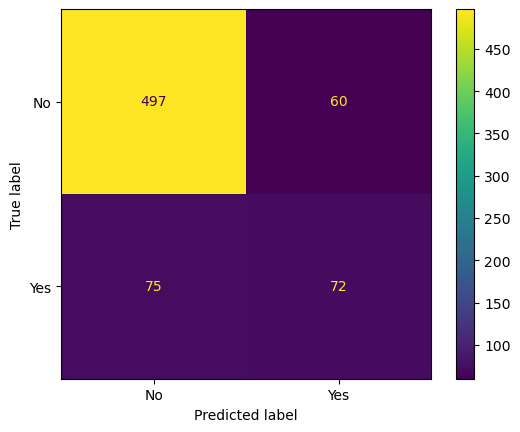

In [106]:
plot_confusion_matrix(dtc,X_test,y_test)

In [108]:
imp_feats = pd.DataFrame(data=dtc.feature_importances_,
                        index=X.columns,
                        columns=['Feat Imp'])

In [111]:
imp_feats = imp_feats.sort_values('Feat Imp')

In [112]:
imp_feats = imp_feats[imp_feats['Feat Imp']>0]

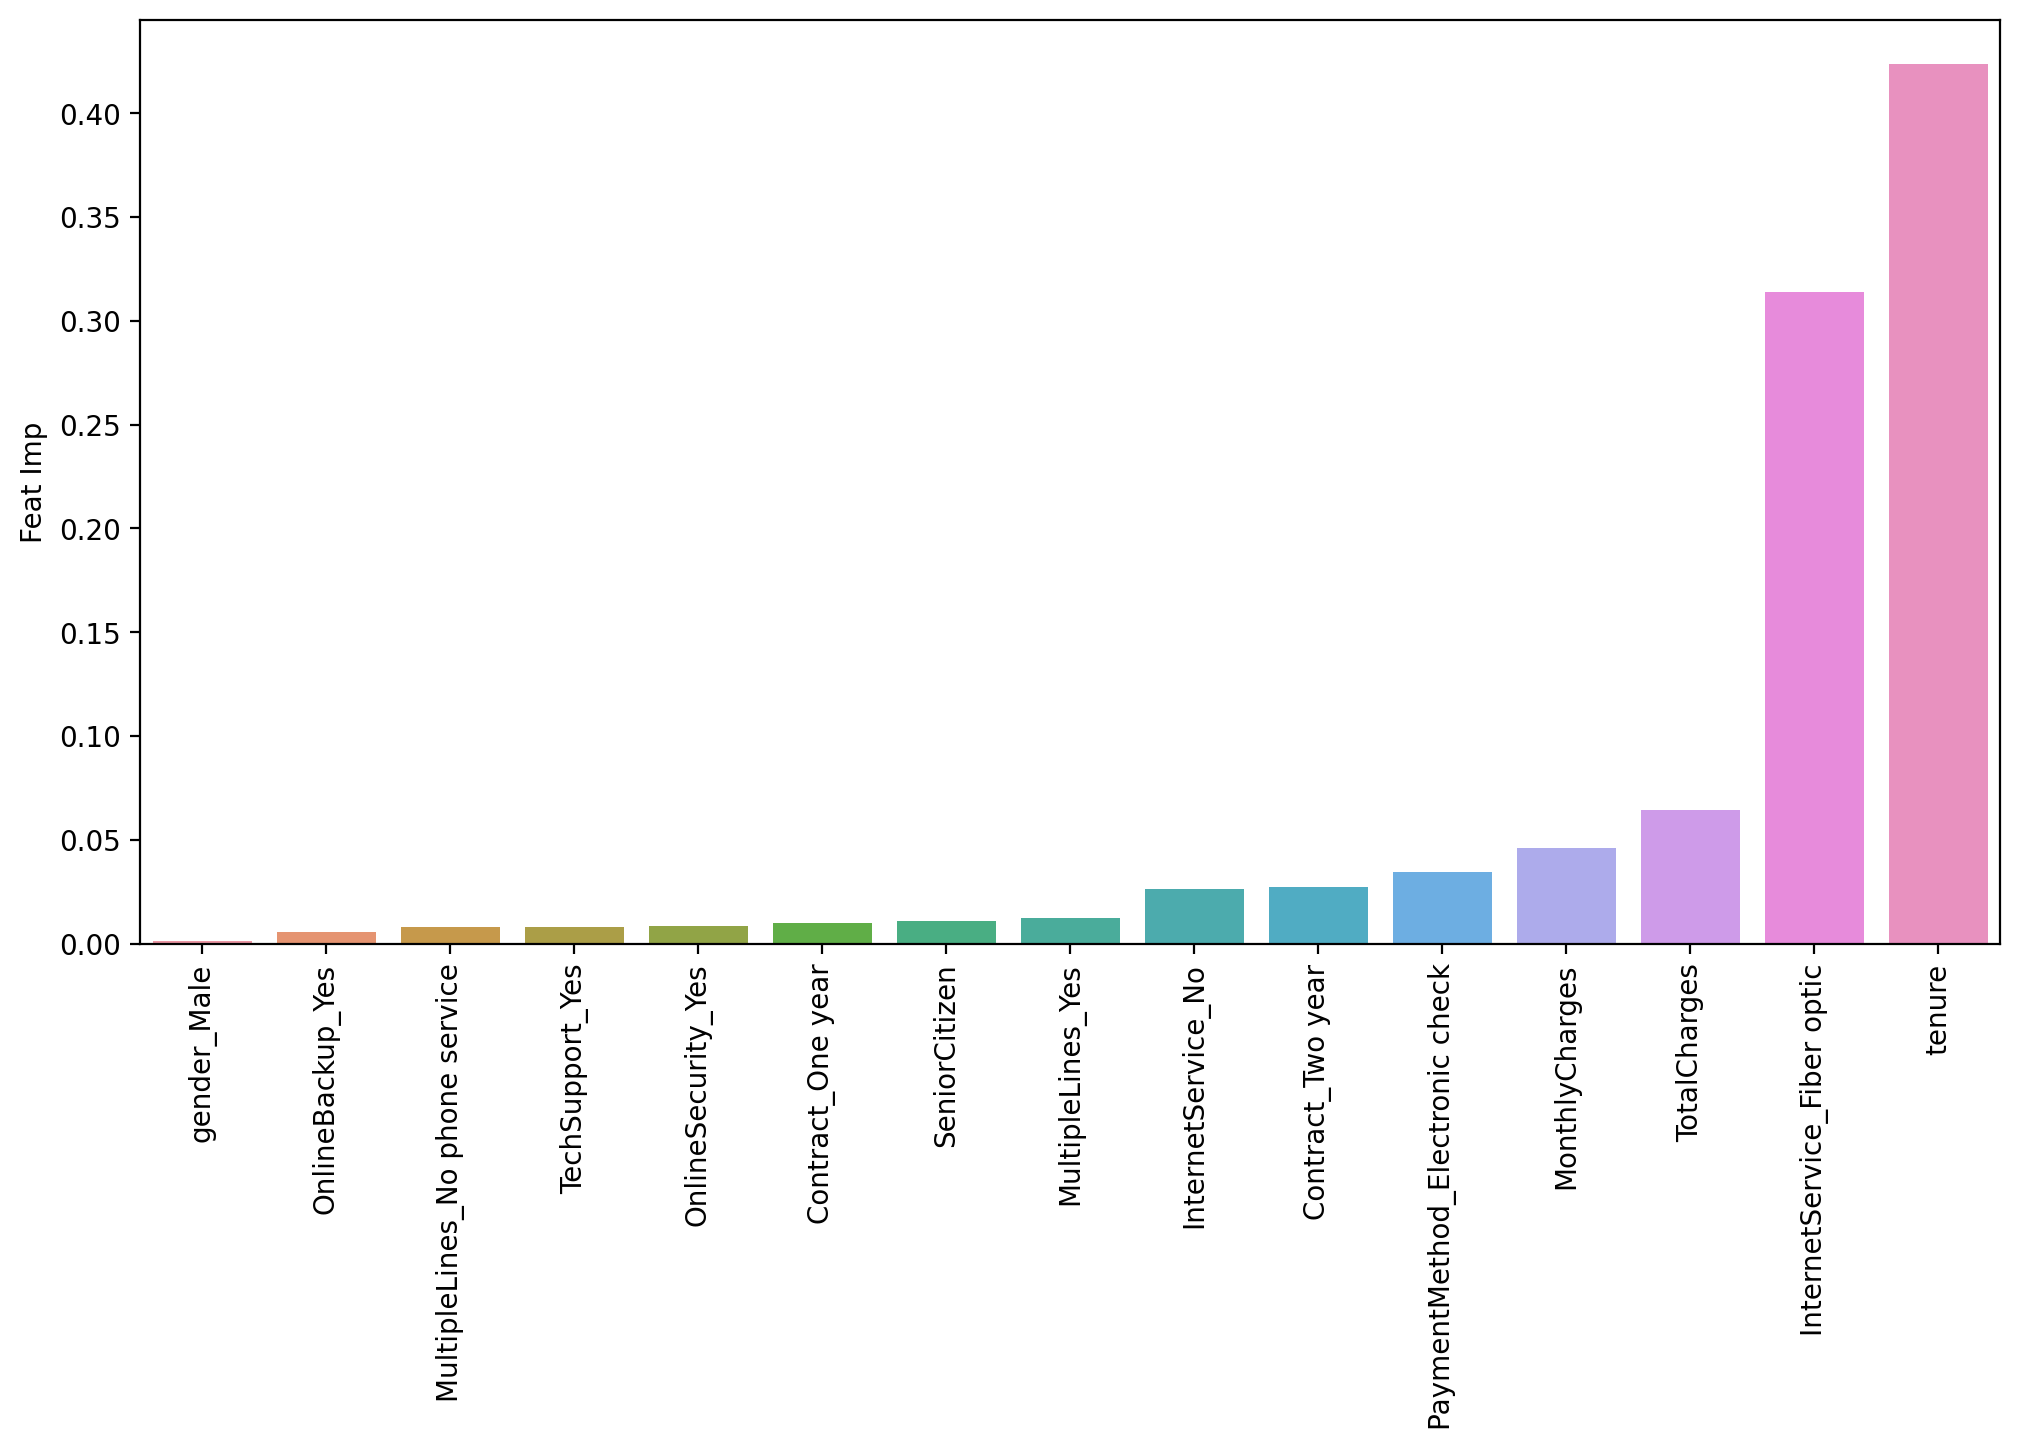

In [117]:
plt.figure(figsize=(12,6),dpi=200)
sns.barplot(data=imp_feats, x=imp_feats.index, y='Feat Imp')
plt.xticks(rotation=90);

In [118]:
from sklearn.tree import plot_tree

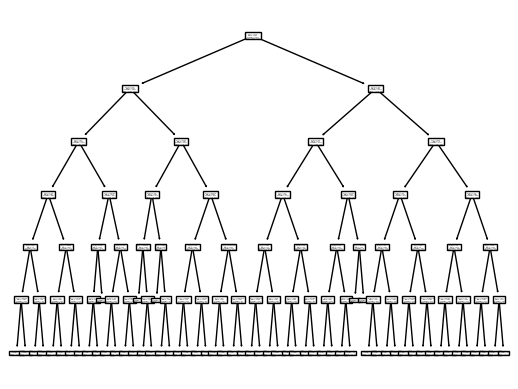

In [120]:
plot_tree(dtc);

RANDOM FOREST

In [121]:
from sklearn.ensemble import RandomForestClassifier

In [126]:
rfc = RandomForestClassifier(max_depth=6)

In [127]:
rfc.fit(X_train,y_train)

RandomForestClassifier(max_depth=6)

In [128]:
preds = rfc.predict(X_test)

In [129]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

          No       0.87      0.92      0.89       557
         Yes       0.61      0.46      0.53       147

    accuracy                           0.83       704
   macro avg       0.74      0.69      0.71       704
weighted avg       0.81      0.83      0.82       704



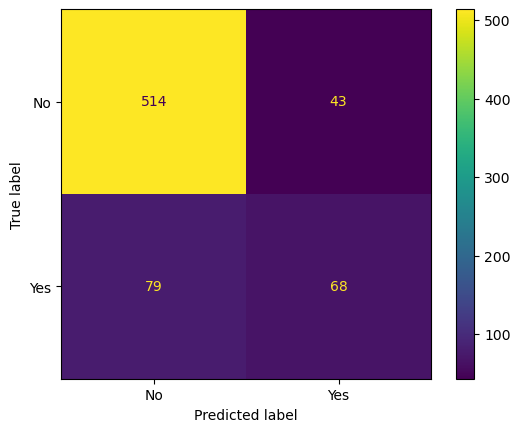

In [130]:
plot_confusion_matrix(rfc,X_test,y_test)

BOOSTED TREES

In [131]:
from sklearn.ensemble import GradientBoostingClassifier,AdaBoostClassifier

ADA BOOST

In [142]:
ada_model = AdaBoostClassifier(n_estimators=100)

In [143]:
ada_model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100)

In [144]:
ada_preds = ada_model.predict(X_test)

In [145]:
print(classification_report(y_test,ada_preds))

              precision    recall  f1-score   support

          No       0.88      0.92      0.90       557
         Yes       0.63      0.53      0.58       147

    accuracy                           0.84       704
   macro avg       0.76      0.72      0.74       704
weighted avg       0.83      0.84      0.83       704



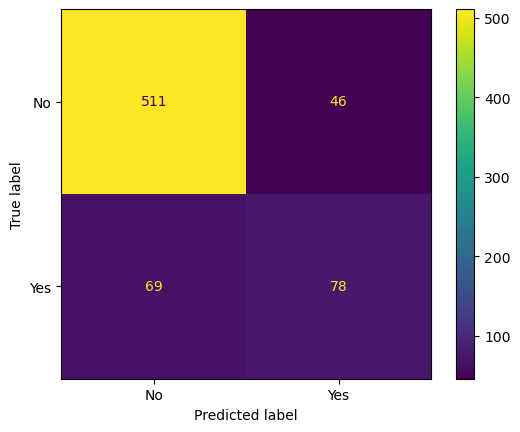

In [146]:
plot_confusion_matrix(ada_model,X_test,y_test)

GRADIENT BOOSTING

In [133]:
gb_model = GradientBoostingClassifier()

In [135]:
gb_model.fit(X_train,y_train)

GradientBoostingClassifier()

In [137]:
gb_preds = gb_model.predict(X_test)

In [140]:
print(classification_report(y_test,gb_preds))

              precision    recall  f1-score   support

          No       0.87      0.90      0.89       557
         Yes       0.57      0.50      0.53       147

    accuracy                           0.82       704
   macro avg       0.72      0.70      0.71       704
weighted avg       0.81      0.82      0.81       704



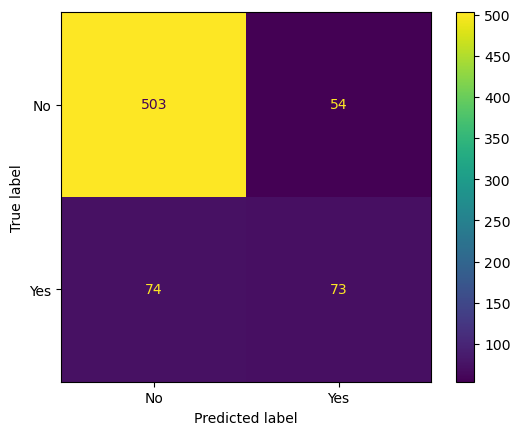

In [147]:
plot_confusion_matrix(gb_model,X_test,y_test)